In [1]:
import gymnasium as gym
import numpy as np

from q_learning import EpsilonGreedy, Qlearning
from quantile_regression import QuantileRegression
from dist_run import Params, run_env, save_experiment, load_experiment
from envs.register import register_envs

register_envs()

params = Params(
    model_name="CliffCustomSlippery-v1",
    total_episodes=10_000,
    learning_rate=0.1,
    gamma=0.95,
    epsilon=0.1,
    seed=123,
    n_runs=1,
    n_quantiles=32,
    action_size=None,
    state_size=None,
    use_lr_decay=True,
    save_skip=100,
    huber_k=1.0
)
rng = np.random.default_rng(params.seed)

In [2]:
env = gym.make(params.model_name, render_mode="rgb_array")
params = params._replace(action_size=int(env.action_space.n))
params = params._replace(state_size=int(env.observation_space.n))
env.action_space.seed(params.seed)

learner = QuantileRegression(params)
explorer = EpsilonGreedy(params.epsilon, rng)
tables = run_env(env, learner, explorer, params)

save_experiment(tables, params)

Run 0/1 - Episodes: 100%|██████████| 10000/10000 [00:13<00:00, 752.88it/s]


In [3]:
tables = tables.mean(0)
qtables = tables.mean(-1) if params.n_quantiles > 1 else tables[-1]
qtable = qtables[-1]

In [8]:
from display_qtables import display_qtables

display_qtables(qtables, env.env.env.shape, decimals=0, grid_size=70)

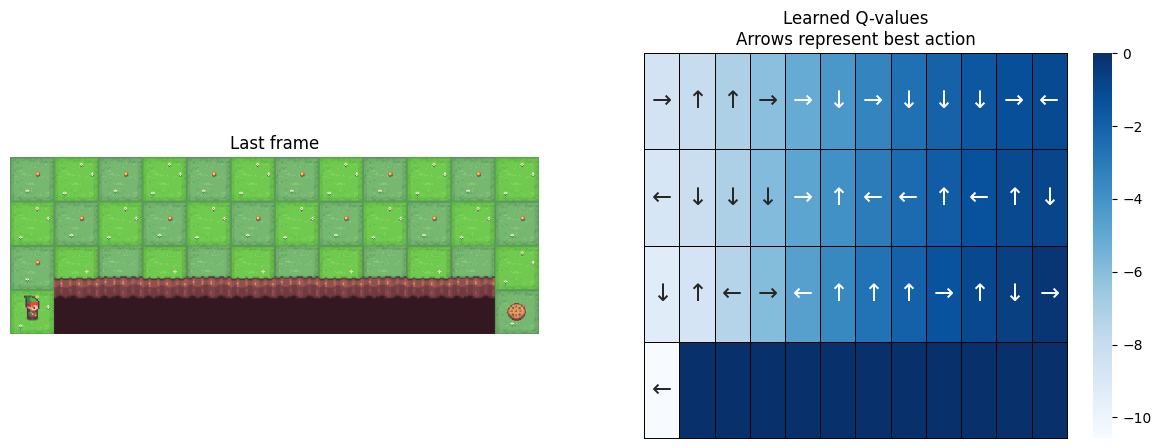

In [4]:
from dist_plot import plot_q_values_map

plot_q_values_map(qtable, env, env.env.env.shape)

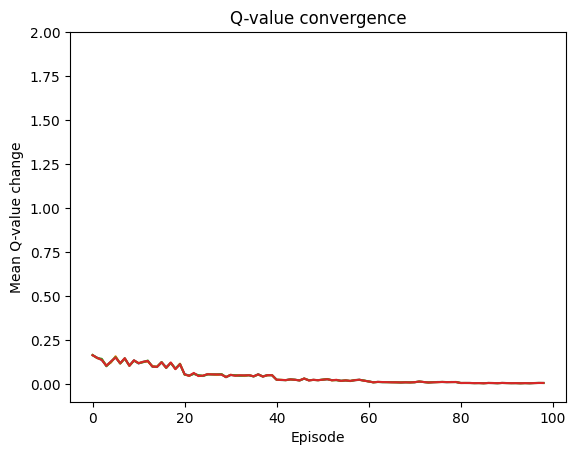

In [5]:
from dist_plot import plot_mean_convergence
plot_mean_convergence(qtables)

In [ ]:
params = Params(
    model_name="WindyRooms-v1",
    total_episodes=10_000,
    learning_rate=0.1,
    gamma=0.99,
    epsilon=0.1,
    map_size=(14, 11),
    seed=256,
    is_slippery=True,
    n_runs=10,
    action_size=None,
    state_size=None,
    n_quantiles=32,
    use_lr_decay=True,
    save_skip=100,
    huber_k=0
)
rng = np.random.default_rng(params.seed)

In [ ]:
env = gym.make(
    params.model_name,
    # is_slippery=params.is_slippery,
    shape=params.map_size,
    step_reward=0,
    goal_reward=1,
    render_mode="rgb_array",
)
params = params._replace(action_size=int(env.action_space.n))
params = params._replace(state_size=int(env.observation_space.n))
env.action_space.seed(params.seed)

learner = QuantileRegression(params)
explorer = EpsilonGreedy(params.epsilon, rng)
tables = run_env(env, learner, explorer, params)

save_experiment(tables, params)

In [ ]:
from dist_run import load_experiment

params, tables = load_experiment()
tables = tables.mean(0)
qtables = tables.mean(-1) if params.n_quantiles > 1 else tables[-1]
qtable = qtables[-1]

In [ ]:
from tqdm import tqdm

test_episodes = 10_000

env = gym.make(
    params.model_name,
    render_mode="rgb_array",
)

total_rewards = []
for episode in tqdm(range(test_episodes)):
    state, info = env.reset() # seed=params.seed?
    done = False
    total_reward = 0

    while not done:
        action = np.argmax(qtable[state])
        next_state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        state = next_state
        done = terminated or truncated

    total_rewards.append(total_reward)

In [ ]:
from dist_plot import plot_q_values_map

plot_q_values_map(qtable, env, params.map_size)

In [ ]:
import matplotlib.pyplot as plt

plt.hist(total_rewards, bins=50, edgecolor="black")
plt.xlabel("Total reward per episode")
plt.ylabel("Frequency")
plt.title("Distribution of Episode Returns")
plt.show()